In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("features_3_sec.csv")

print(df.head())

print(df['label'].value_counts())


            filename  length  chroma_stft_mean  chroma_stft_var  rms_mean  \
0  blues.00000.0.wav   66149          0.335406         0.091048  0.130405   
1  blues.00000.1.wav   66149          0.343065         0.086147  0.112699   
2  blues.00000.2.wav   66149          0.346815         0.092243  0.132003   
3  blues.00000.3.wav   66149          0.363639         0.086856  0.132565   
4  blues.00000.4.wav   66149          0.335579         0.088129  0.143289   

    rms_var  spectral_centroid_mean  spectral_centroid_var  \
0  0.003521             1773.065032          167541.630869   
1  0.001450             1816.693777           90525.690866   
2  0.004620             1788.539719          111407.437613   
3  0.002448             1655.289045          111952.284517   
4  0.001701             1630.656199           79667.267654   

   spectral_bandwidth_mean  spectral_bandwidth_var  ...  mfcc16_var  \
0              1972.744388           117335.771563  ...   39.687145   
1              2010.05

In [ ]:
X = df.drop(columns=['filename', 'length', 'label'])

y = df['label']

In [13]:
df.isnull().sum()

filename                   0
length                     0
chroma_stft_mean           0
chroma_stft_var            0
rms_mean                   0
rms_var                    0
spectral_centroid_mean     0
spectral_centroid_var      0
spectral_bandwidth_mean    0
spectral_bandwidth_var     0
rolloff_mean               0
rolloff_var                0
zero_crossing_rate_mean    0
zero_crossing_rate_var     0
harmony_mean               0
harmony_var                0
perceptr_mean              0
perceptr_var               0
tempo                      0
mfcc1_mean                 0
mfcc1_var                  0
mfcc2_mean                 0
mfcc2_var                  0
mfcc3_mean                 0
mfcc3_var                  0
mfcc4_mean                 0
mfcc4_var                  0
mfcc5_mean                 0
mfcc5_var                  0
mfcc6_mean                 0
mfcc6_var                  0
mfcc7_mean                 0
mfcc7_var                  0
mfcc8_mean                 0
mfcc8_var     

In [ ]:
# Train/Test split:-
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 7992
Testing set size: 1998


In [17]:
# Model Training:-
# For multi-class problems like genre detection we will use Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# n_estimators=100 means we are using 100 decision trees
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [19]:
# Initial Evaluation using metrics:-
from sklearn.metrics import accuracy_score

# make predictions on the test set
y_pred = model.predict(X_test)

# calulate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 87.29%


In [20]:
# Precision, Recall, and F1-Score are standard evaluation metrics used to measure the performance of classification models in machine learning
# Detailed Evaluation:-
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       blues       0.87      0.85      0.86       208
   classical       0.92      0.98      0.95       203
     country       0.74      0.82      0.78       186
       disco       0.88      0.84      0.86       199
      hiphop       0.91      0.87      0.89       218
        jazz       0.84      0.90      0.87       192
       metal       0.90      0.95      0.92       204
         pop       0.93      0.94      0.93       180
      reggae       0.90      0.85      0.87       211
        rock       0.85      0.74      0.79       197

    accuracy                           0.87      1998
   macro avg       0.87      0.87      0.87      1998
weighted avg       0.87      0.87      0.87      1998



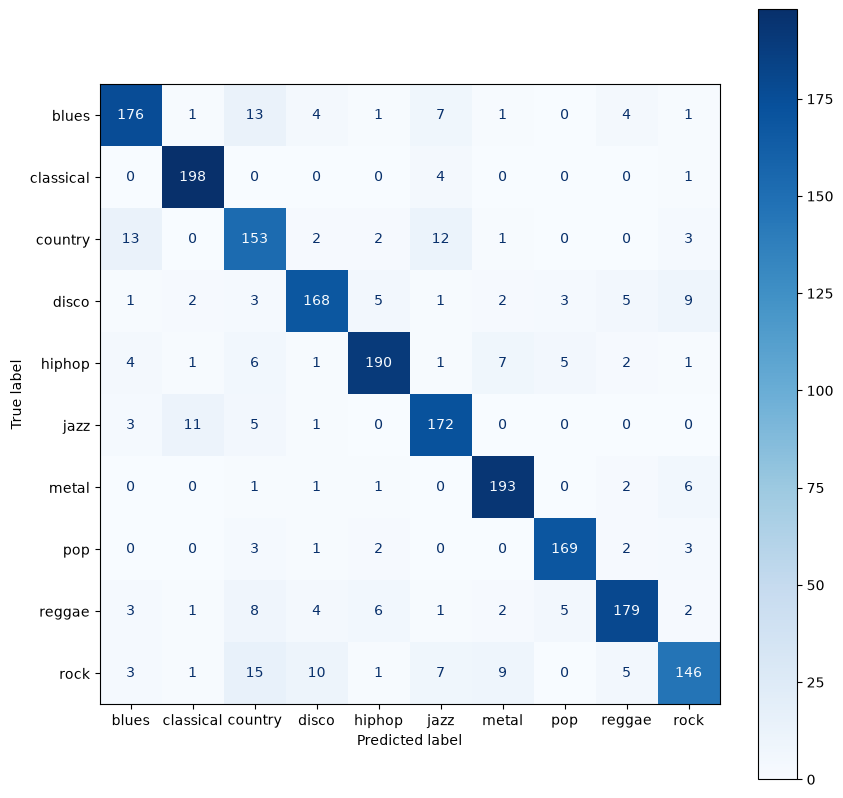

In [23]:
# Visualize errors:-
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(cmap='Blues', ax=ax, xticks_rotation='horizontal')
plt.show()

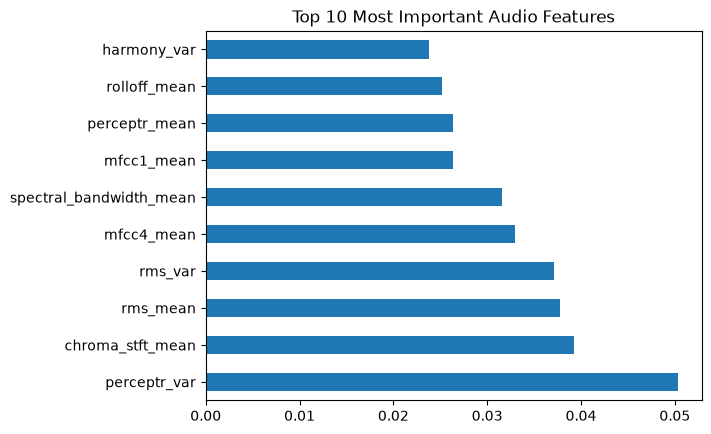

In [24]:
# Feature Importances:-
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Most Important Audio Features")
plt.show()

In [25]:
# Below are measures to improve the model---

In [27]:
# 1. Hyperparameter Tuning(Grid Search)
# This finds the best settings for your Random Forest

from sklearn.model_selection import GridSearchCV

# define params to test
param_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2,5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}


In [28]:
# 2. Gradient Boosting:-
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost requires numeric labels (0, 1, 2...)
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)

# initialize and train XGBoost
xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train_num)

# Evaluate XGBoost
xgb_acc = xgb_model.score(X_test, y_test_num)
print(f"XGboost Accuracy: {xgb_acc * 100:.2f}%")

XGboost Accuracy: 91.84%


In [29]:
# 3. Cross-Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf_model, X, y, cv=5)

print(f"All CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}%")

All CV Scores: [0.48748749 0.62512513 0.56356356 0.56306306 0.45145145]
Mean CV Accuracy: 53.81%


In [30]:
# CLEARLY XGBoost is the winner, we will use this model as it gives us an accuracy of 91.54%

In [31]:
# Saving the XGBoost model and LabelEncoder
import joblib

# saving the winning model
joblib.dump(xgb_model, 'music_genre_xgb.pkl')

# saving the encoder
joblib.dump(le, 'label_encoder.pkl')

print("XGBoost model and LabelEncoder saved!")

XGBoost model and LabelEncoder saved!
